# 02 — Feature Engineering

Encode categorical 5G features, create time/lag/rolling features. Import reusable logic from `src.preprocessing`.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_loader import load_raw
from src.preprocessing import clean, encode_categorical, add_time_features, add_lag_features, build_features

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
# Load & clean
df_raw = load_raw()
df_clean = clean(df_raw)
print(f'After cleaning: {df_clean.shape}')

After cleaning: (188711, 28)


In [3]:
# Encode categorical columns
df_enc = encode_categorical(df_clean)
print('Categorical columns encoded:')
for col in config.CATEGORICAL_COLUMNS:
    print(f'  {col}: {df_enc[col].nunique()} unique values')
df_enc.head()

Categorical columns encoded:
  NetworkMode: 8 unique values
  Operatorname: 3 unique values
  Application: 3 unique values
  Mobility: 2 unique values
  State: 4 unique values


,Timestamp,Longitude,Latitude,Speed,Operatorname,CellID,NetworkMode,RSRP,RSRQ,SNR,...,PINGSTDEV,PINGLOSS,CELLHEX,NODEHEX,LACHEX,RAWCELLID,NRxRSRP,NRxRSRQ,Application,Mobility
0,2019-11-20 16:55:16,-8.499476,51.893446,0,2,3,6,-79,-12.0,10.0,...,3.0,0.0,3,76C6C,9CBA,124546051,-77.0,-13.0,2,0
1,2019-11-20 16:55:16,-8.499567,51.893413,0,2,3,6,-79,-12.0,10.0,...,3.0,0.0,3,76C6C,9CBA,124546051,-77.0,-13.0,2,0
2,2019-11-20 16:55:16,-8.499567,51.893413,0,2,3,6,-79,-12.0,7.0,...,3.0,0.0,3,76C6C,9CBA,124546051,-77.0,-13.0,2,0
3,2019-11-20 16:55:17,-8.499567,51.893413,0,2,3,6,-79,-12.0,7.0,...,3.0,0.0,3,76C6C,9CBA,124546051,-77.0,-13.0,2,0
4,2019-11-20 16:55:18,-8.499567,51.893413,0,2,3,6,-78,-12.0,10.0,...,3.0,0.0,3,76C6C,9CBA,124546051,-77.0,-13.0,2,0


In [4]:
# Add time features
df_time = add_time_features(df_enc)
df_time[[config.TARGET_COLUMN, 'hour', 'weekday', 'is_weekend']].head()

,DL_bitrate,hour,weekday,is_weekend
0,2,16,2,0
1,2,16,2,0
2,0,16,2,0
3,0,16,2,0
4,2,16,2,0


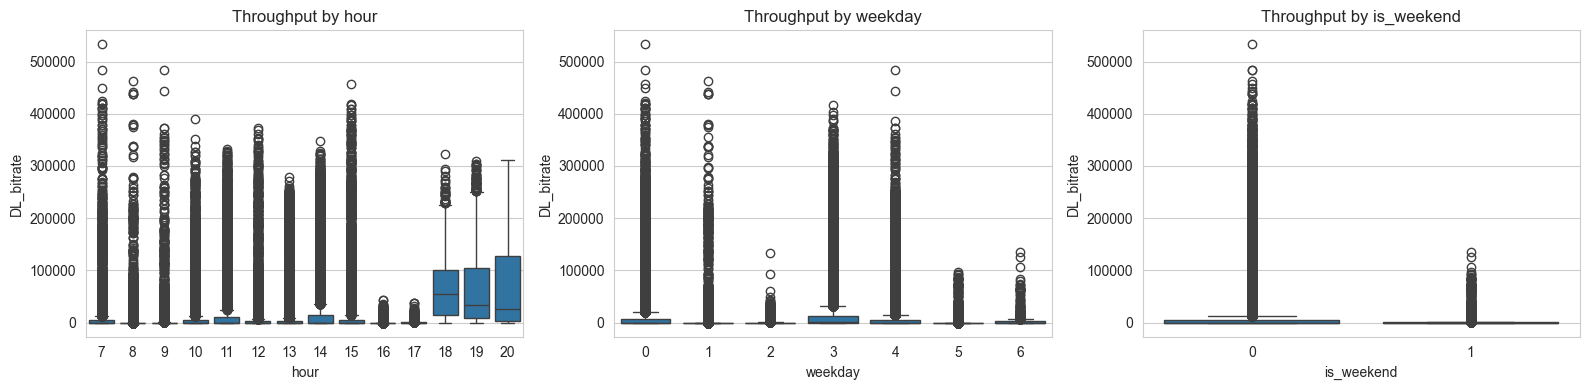

In [5]:
# Visualise feature relationships with target
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['hour', 'weekday', 'is_weekend']):
    sns.boxplot(x=df_time[col], y=df_time[config.TARGET_COLUMN], ax=ax)
    ax.set_title(f'Throughput by {col}')
plt.tight_layout()

In [6]:
# Full feature pipeline
df_full = build_features(df_raw)
print(f'Final processed shape: {df_full.shape}')
print(f'Feature columns ({len(config.FEATURE_COLUMNS)}):')
for f in config.FEATURE_COLUMNS:
    print(f'  {f}')

Final processed shape: (188702, 38)
Feature columns (24):
  Speed
  RSRP
  RSRQ
  SNR
  CQI
  RSSI
  UL_bitrate
  Longitude
  Latitude
  NetworkMode
  Operatorname
  Application
  Mobility
  State
  hour
  weekday
  is_weekend
  lag_1
  lag_2
  lag_3
  rolling_mean_3
  rolling_mean_6
  rolling_std_3
  rolling_std_6


Text(0.5, 1.0, 'Feature Correlation Matrix')

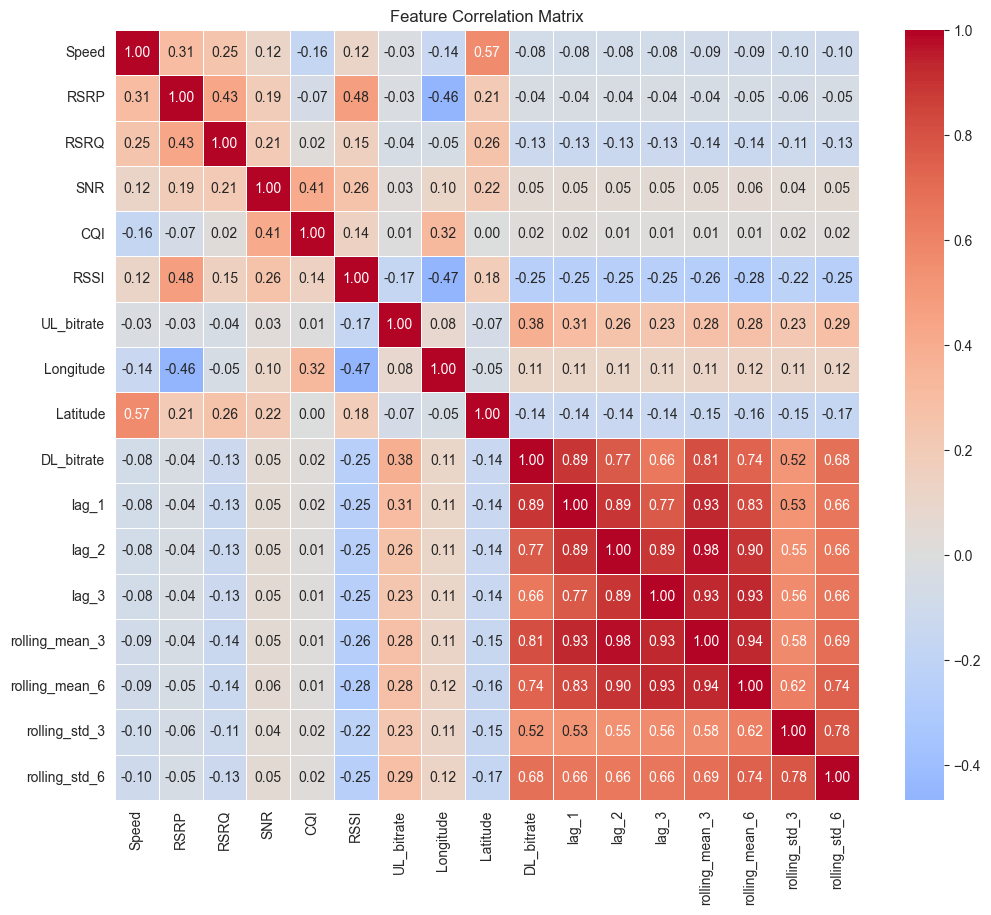

In [7]:
# Correlation heatmap of numeric features vs target
plt.figure(figsize=(12, 10))
num_cols = config.NUMERIC_COLUMNS + [config.TARGET_COLUMN] + config.LAG_FEATURES + config.ROLLING_FEATURES
corr = df_full[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')

## Notes
- 5 categorical columns label-encoded: NetworkMode, Operatorname, Application, Mobility, State
- 9 numeric RF features: Speed, RSRP, RSRQ, SNR, CQI, RSSI, UL_bitrate, Longitude, Latitude
- 3 time features + 3 lag features + 4 rolling features added
- Total: 24 feature columns for tree/linear models (label-encoded categoricals)
- LSTM uses one-hot encoding (not label encoding) — 9 numeric + 3 time + ~20 one-hot dummies
- LSTM+lag variant adds the same lag/rolling features on top of one-hot encoded data